In [5]:
import os
import time
import numpy as np
import polars as pl
import optuna
import psutil
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

HAS_GPU = len(tf.config.list_physical_devices('GPU')) > 0
TRAIN_DEVICE = '/GPU:0' if HAS_GPU else '/CPU:0'
INFER_DEVICE = '/CPU:0'

if HAS_GPU:
    print('GPU detectada. El entrenamiento se ejecutara en GPU y la inferencia se medira en CPU.')
else:
    print('No hay GPU disponible. Entrenamiento e inferencia se ejecutaran en CPU.')

tf.keras.backend.clear_session()


GPU detectada. El entrenamiento se ejecutara en GPU y la inferencia se medira en CPU.


In [6]:
DEFAULT_DROPOUT_RATE = 0.2

def build_cnn1d_model(n_features, n_filters, kernel_size, dense_units, dropout_rate=DEFAULT_DROPOUT_RATE):
    model = keras.Sequential([
        keras.layers.Input(shape=(n_features, 1)), # <-- Forma tabular (características como secuencia)
        keras.layers.Conv1D(filters=n_filters, kernel_size=kernel_size, padding='same', activation='relu'),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Conv1D(filters=max(16, n_filters // 2), kernel_size=kernel_size, padding='same', activation='relu'),
        keras.layers.GlobalMaxPooling1D(),
        keras.layers.Dense(dense_units, activation='relu'),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def clone_model_to_cpu(trained_model, n_features, n_filters, kernel_size, dense_units, dropout_rate):
    with tf.device(INFER_DEVICE):
        cpu_model = build_cnn1d_model(
            n_features=n_features,
            n_filters=n_filters,
            kernel_size=kernel_size,
            dense_units=dense_units,
            dropout_rate=dropout_rate
        )
        cpu_model.set_weights(trained_model.get_weights())
    return cpu_model

# --- CARGA DEL DATASET UNSW-NB15 ---
path_train = '../../DATASETS/dataSets_Reducidos/nusw-nb15/datos_train_NUSW_redux.csv'
path_test  = '../../DATASETS/dataSets_Reducidos/nusw-nb15/datos_test_NUSW_redux.csv'

df_train = pl.read_csv(path_train)
df_test  = pl.read_csv(path_test)
TARGET_COL = 'attack_cat'

y_train = (
    df_train.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == 'Normal')
        .then(1)
        .otherwise(-1)
        .alias('label')
    )
    .to_series()
    .cast(pl.Int8)
)

y_test = (
    df_test.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == 'Normal')
        .then(1)
        .otherwise(-1)
        .alias('label')
    )
    .to_series()
    .cast(pl.Int8)
)

x_train = df_train.drop(TARGET_COL)
x_test = df_test.drop(TARGET_COL)

X_full_train = x_train.to_numpy()
y_full_train = y_train.to_numpy()
X_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

# Convertimos de {-1, 1} a {0, 1} para entrenar con entropía cruzada binaria
y_full_train_01 = ((y_full_train + 1) // 2).astype(np.int8)
y_test_np01 = ((y_test_np + 1) // 2).astype(np.int8)

X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_full_train,
    y_full_train,
    test_size=0.2,
    random_state=42,
    stratify=y_full_train
)

print(f'Forma de X_full_train: {X_full_train.shape}')
print(f'Forma de X_test: {X_test_np.shape}')
print('Distribución de clases en train:')
print(y_train.value_counts())
print('Distribución de clases en test:')
print(y_test.value_counts())
print('\nNota metodológica: La CNN-1D procesa cada flujo de forma independiente como un vector tabular, utilizando las características extraídas para encontrar correlaciones locales.')

Forma de X_full_train: (175341, 12)
Forma de X_test: (82332, 12)
Distribución de clases en train:
shape: (2, 2)
┌───────┬────────┐
│ label ┆ count  │
│ ---   ┆ ---    │
│ i8    ┆ u32    │
╞═══════╪════════╡
│ -1    ┆ 119341 │
│ 1     ┆ 56000  │
└───────┴────────┘
Distribución de clases en test:
shape: (2, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i8    ┆ u32   │
╞═══════╪═══════╡
│ 1     ┆ 37000 │
│ -1    ┆ 45332 │
└───────┴───────┘

Nota metodológica: La CNN-1D procesa cada flujo de forma independiente como un vector tabular, utilizando las características extraídas para encontrar correlaciones locales.


In [8]:
# ==========================================
# 2. OPTUNA MULTIOBJETIVO: F1 Y LATENCIA
# ==========================================

def objective(trial):
    tf.keras.backend.clear_session()

    n_filters = trial.suggest_int('n_filters', 32, 128, step=32)
    kernel_size = trial.suggest_int('kernel_size', 2, 5)
    dense_units = trial.suggest_int('dense_units', 16, 96, step=16)
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = []
    inference_times = []

    for train_idx, val_idx in skf.split(X_full_train, y_full_train_01):
        X_train_fold = X_full_train[train_idx]
        y_train_fold = y_full_train_01[train_idx]
        X_val_fold = X_full_train[val_idx]
        y_val_fold = y_full_train_01[val_idx]

        # 1. Escalado Min-Max
        scaler = MinMaxScaler()
        X_train_fold_scaled = scaler.fit_transform(X_train_fold)
        X_val_fold_scaled = scaler.transform(X_val_fold)

        # 2. Reshape Tabular a 3D para la Conv1D (muestras, features, canales)
        X_train_cnn = X_train_fold_scaled.reshape(X_train_fold_scaled.shape[0], X_train_fold_scaled.shape[1], 1)
        X_val_cnn = X_val_fold_scaled.reshape(X_val_fold_scaled.shape[0], X_val_fold_scaled.shape[1], 1)
        
        n_features = X_train_cnn.shape[1]

        with tf.device(INFER_DEVICE):
            model = build_cnn1d_model(
                n_features=n_features,
                n_filters=n_filters,
                kernel_size=kernel_size,
                dense_units=dense_units,
                dropout_rate=DEFAULT_DROPOUT_RATE
            )

            early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
            model.fit(
                X_train_cnn,
                y_train_fold,
                validation_split=0.1,
                epochs=20,
                batch_size=1024,
                callbacks=[early_stop],
                verbose=0
            )

        cpu_model = clone_model_to_cpu(
            trained_model=model,
            n_features=n_features,
            n_filters=n_filters,
            kernel_size=kernel_size,
            dense_units=dense_units,
            dropout_rate=DEFAULT_DROPOUT_RATE
        )

        with tf.device(INFER_DEVICE):
            y_pred_prob = cpu_model.predict(X_val_cnn, batch_size=1024, verbose=0).ravel()

        y_pred = (y_pred_prob > 0.5).astype(np.int8)
        f1_scores.append(f1_score(y_val_fold, y_pred, average='macro', zero_division=0))

        X_lat = X_val_cnn[:min(20000, len(X_val_cnn))]
        if len(X_lat) == 0:
            continue

        with tf.device(INFER_DEVICE):
            _ = cpu_model.predict(X_lat[:min(512, len(X_lat))], batch_size=512, verbose=0)

        rep_lat = []
        for _ in range(3):
            with tf.device(INFER_DEVICE):
                t0 = time.perf_counter()
                _ = cpu_model.predict(X_lat, batch_size=1024, verbose=0)
                t1 = time.perf_counter()
            rep_lat.append((t1 - t0) / len(X_lat))

        inference_times.append(float(np.mean(rep_lat)))

        tf.keras.backend.clear_session()

    return float(np.mean(f1_scores)), float(np.mean(inference_times))

study = optuna.create_study(directions=['maximize', 'minimize'], study_name='cnn1d_unsw_optimization')
print('Iniciando barrido multiobjetivo con CNN-1D (entrenamiento en GPU, inferencia medida en CPU)...')
study.optimize(objective, n_trials=25, show_progress_bar=True)

results = []
pareto_trials = {trial.number for trial in study.best_trials}
for trial in study.trials:
    if trial.values is None:
        continue

    row = {
        'Trial': trial.number,
        'F1_CV': float(trial.values[0]),
        'Latencia_ms': float(trial.values[1] * 1000),
        'Pareto': trial.number in pareto_trials
    }
    row.update(trial.params)
    results.append(row)

df_cnn_trials = pl.DataFrame(results).sort(['Pareto', 'F1_CV', 'Latencia_ms'], descending=[True, True, False])
df_cnn_trials.write_csv('cnn1d_unsw_trials_results_cv.csv')
print("\nResultados guardados en 'cnn1d_unsw_trials_results_cv.csv'")
print(df_cnn_trials)

[I 2026-04-28 19:05:48,345] A new study created in memory with name: cnn1d_unsw_optimization


Iniciando barrido multiobjetivo con CNN-1D (entrenamiento en GPU, inferencia medida en CPU)...


  4%|▍         | 1/25 [00:48<19:15, 48.13s/it]

[I 2026-04-28 19:06:36,477] Trial 0 finished with values: [0.894690057528087, 8.226580699233132e-06] and parameters: {'n_filters': 96, 'kernel_size': 2, 'dense_units': 96}.


  8%|▊         | 2/25 [01:35<18:17, 47.72s/it]

...

[I 2026-04-28 19:23:38,916] Trial 22 finished with values: [0.8958279888561668, 8.401631414502238e-06] and parameters: {'n_filters': 32, 'kernel_size': 5, 'dense_units': 16}.


 96%|█████████▌| 24/25 [18:26<00:40, 40.96s/it]

[I 2026-04-28 19:24:14,932] Trial 23 finished with values: [0.8922904438345659, 8.57814933406189e-06] and parameters: {'n_filters': 32, 'kernel_size': 3, 'dense_units': 80}.


100%|██████████| 25/25 [19:23<00:00, 46.53s/it]

[I 2026-04-28 19:25:11,518] Trial 24 finished with values: [0.8986468707830827, 8.926624899807697e-06] and parameters: {'n_filters': 128, 'kernel_size': 3, 'dense_units': 48}.

Resultados guardados en 'cnn1d_unsw_trials_results_cv.csv'
shape: (25, 7)
┌───────┬──────────┬─────────────┬────────┬───────────┬─────────────┬─────────────┐
│ Trial ┆ F1_CV    ┆ Latencia_ms ┆ Pareto ┆ n_filters ┆ kernel_size ┆ dense_units │
│ ---   ┆ ---      ┆ ---         ┆ ---    ┆ ---       ┆ ---         ┆ ---         │
│ i64   ┆ f64      ┆ f64         ┆ bool   ┆ i64       ┆ i64         ┆ i64         │
╞═══════╪══════════╪═════════════╪════════╪═══════════╪═════════════╪═════════════╡
│ 11    ┆ 0.902863 ┆ 0.008997    ┆ true   ┆ 128       ┆ 5           ┆ 64          │
│ 14    ┆ 0.900451 ┆ 0.008755    ┆ true   ┆ 64        ┆ 5           ┆ 48          │
│ 22    ┆ 0.895828 ┆ 0.008402    ┆ true   ┆ 32        ┆ 5           ┆ 16          │
│ 0     ┆ 0.89469  ┆ 0.008227    ┆ true   ┆ 96        ┆ 2           ┆ 96     

Trial,F1_CV,Latencia_ms,Pareto,n_filters,kernel_size,dense_units
i64,f64,f64,bool,i64,i64,i64
0,0.89469,0.008227,true,96,2,96
22,0.895828,0.008402,true,32,5,16
14,0.900451,0.008755,true,64,5,48
11,0.902863,0.008997,true,128,5,64


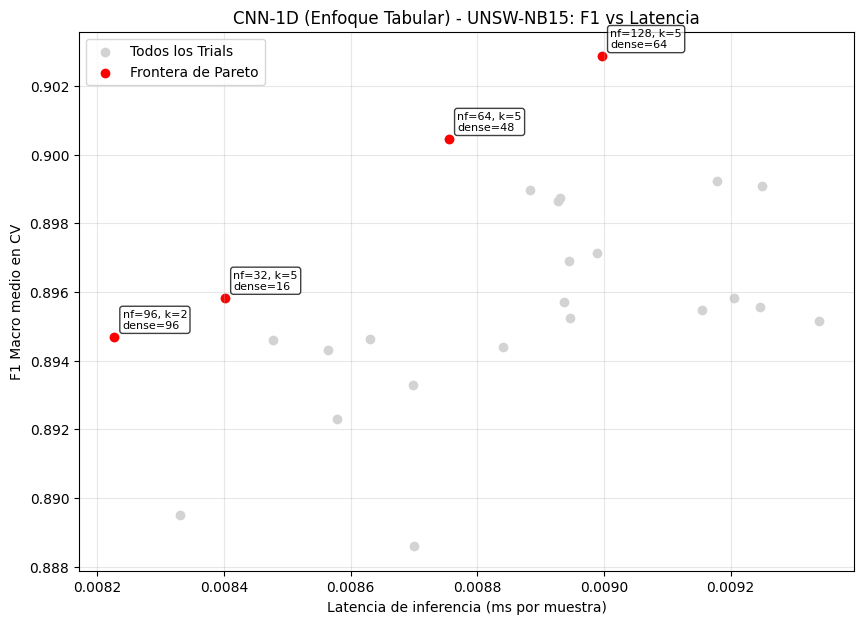

In [10]:
import polars as pl
import matplotlib.pyplot as plt

# 1. Leer resultados desde el CSV específico de UNSW-NB15
df_cnn_trials = pl.read_csv("cnn1d_unsw_trials_results_cv.csv")

# 2. Filtrar la frontera de Pareto
df_pareto = (
    df_cnn_trials
    .filter(pl.col("Pareto") == True)
    .sort("Latencia_ms")
)

display(df_pareto)

# 3. Configurar la gráfica
plt.figure(figsize=(10, 7))

# Puntos grises para todos los intentos (Trials)
plt.scatter(
    df_cnn_trials["Latencia_ms"],
    df_cnn_trials["F1_CV"],
    c="lightgray",
    label="Todos los Trials"
)

# Puntos rojos para los óptimos (Frontera de Pareto)
plt.scatter(
    df_pareto["Latencia_ms"],
    df_pareto["F1_CV"],
    c="red",
    label="Frontera de Pareto"
)

# 4. Mostrar hiperparámetros de los puntos Pareto (¡Sin time_steps!)
for row in df_pareto.iter_rows(named=True):
    # Formateamos el texto solo con los hiperparámetros que hemos usado
    texto = (
        f"nf={row['n_filters']}, k={row['kernel_size']}\n"
        f"dense={row['dense_units']}"
    )
    plt.annotate(
        texto,
        (row["Latencia_ms"], row["F1_CV"]),
        textcoords="offset points",
        xytext=(6, 6),
        ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.75)
    )

# 5. Etiquetas y formato final
plt.xlabel("Latencia de inferencia (ms por muestra)")
plt.ylabel("F1 Macro medio en CV")
plt.title("CNN-1D (Enfoque Tabular) - UNSW-NB15: F1 vs Latencia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [12]:
import gc
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, accuracy_score

# ==========================================
# 4. EVALUACION FINAL EN TEST (CNN-1D TABULAR)
# ==========================================

candidatos = [
    {'nf': 128, 'k': 5, 'd': 64, 'nombre': 'Candidato 1'},
    {'nf': 64, 'k': 5, 'd': 48, 'nombre': 'Candidato 2'},
    {'nf': 32, 'k': 5, 'd': 16, 'nombre': 'Candidato 3'},
    {'nf': 96, 'k': 2, 'd': 96, 'nombre': 'Candidato 4'},
]

resultados_finales = []

print('--- EVALUACION FINAL SOBRE EL SET DE TEST (CNN-1D TABULAR) ---\n')

for c in candidatos:
    tf.keras.backend.clear_session()
    print(
        f"Probando {c['nombre']}: Filtros={c['nf']}, "
        f"Kernel={c['k']}, Dense={c['d']}"
    )

    n_filters = int(c['nf'])
    kernel_size = int(c['k'])
    dense_units = int(c['d'])

    # 1. Usamos MinMaxScaler en lugar de StandardScaler (Vital para CNN)
    scaler = MinMaxScaler()
    X_full_train_scaled = scaler.fit_transform(X_full_train)
    X_test_scaled = scaler.transform(X_test_np)

    # 2. Reshape Tabular a 3D (muestras, features, canales)
    X_train_cnn = X_full_train_scaled.reshape(X_full_train_scaled.shape[0], X_full_train_scaled.shape[1], 1)
    X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
    
    n_features = X_train_cnn.shape[1]

    with tf.device(INFER_DEVICE):
        model = build_cnn1d_model(
            n_features=n_features,
            n_filters=n_filters,
            kernel_size=kernel_size,
            dense_units=dense_units,
            dropout_rate=DEFAULT_DROPOUT_RATE
        )

        early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        model.fit(
            X_train_cnn,
            y_full_train_01, # Usamos las etiquetas 0/1 correctas
            validation_split=0.1,
            epochs=20,
            batch_size=512,  # Reducido a 512 para no saturar la GPU
            callbacks=[early_stop],
            verbose=0
        )

    # Clonamos a CPU para una medición de latencia justa
    cpu_model = clone_model_to_cpu(
        trained_model=model,
        n_features=n_features,
        n_filters=n_filters,
        kernel_size=kernel_size,
        dense_units=dense_units,
        dropout_rate=DEFAULT_DROPOUT_RATE
    )

    with tf.device(INFER_DEVICE):
        y_prob = cpu_model.predict(X_test_cnn, batch_size=1024, verbose=0).ravel()
    
    y_pred = (y_prob > 0.5).astype(np.int8)

    # Preparar datos para latencia
    X_lat = X_test_cnn[:min(20000, len(X_test_cnn))]
    if len(X_lat) == 0:
        raise ValueError('No hay suficientes muestras en test para medir latencia con la configuracion seleccionada.')

    # Calentamiento (Warm-up)
    with tf.device(INFER_DEVICE):
        _ = cpu_model.predict(X_lat[:min(512, len(X_lat))], batch_size=512, verbose=0)

    # Medición real
    rep_lat = []
    for _ in range(3):
        with tf.device(INFER_DEVICE):
            t0 = time.perf_counter()
            _ = cpu_model.predict(X_lat, batch_size=1024, verbose=0)
            t1 = time.perf_counter()
        rep_lat.append((t1 - t0) / len(X_lat))

    # Cálculo final de métricas (evaluando sobre y_test_np01)
    f1_test = float(f1_score(y_test_np01, y_pred, average='macro', zero_division=0))
    acc_test = float(accuracy_score(y_test_np01, y_pred))
    lat_ms = float(np.mean(rep_lat) * 1000)

    resultados_finales.append({
        'Perfil': c['nombre'],
        'n_filters': n_filters,
        'kernel_size': kernel_size,
        'dense_units': dense_units,
        'F1_Test': f1_test,
        'Accuracy_Test': acc_test,
        'Latencia_ms': lat_ms
    })
    print(f"  -> F1={f1_test:.4f} | Acc={acc_test:.4f} | Latencia={lat_ms:.6f} ms")

    # Limpieza estricta de memoria
    del model
    del cpu_model
    tf.keras.backend.clear_session()
    gc.collect()

# Mostrar DataFrame final
df_candidate_results = pl.DataFrame(resultados_finales).sort(['F1_Test', 'Latencia_ms'], descending=[True, False])

print('\n' + '=' * 88)
print('              TABLA COMPARATIVA FINAL (CNN-1D TABULAR - TEST SET)')
print('=' * 88)
print(df_candidate_results)

--- EVALUACION FINAL SOBRE EL SET DE TEST (CNN-1D TABULAR) ---

Probando Candidato 1: Filtros=128, Kernel=5, Dense=64
  -> F1=0.7619 | Acc=0.7841 | Latencia=0.009398 ms
Probando Candidato 2: Filtros=64, Kernel=5, Dense=48
  -> F1=0.7731 | Acc=0.7930 | Latencia=0.008880 ms
Probando Candidato 3: Filtros=32, Kernel=5, Dense=16
  -> F1=0.7383 | Acc=0.7655 | Latencia=0.008725 ms
Probando Candidato 4: Filtros=96, Kernel=2, Dense=96
  -> F1=0.7497 | Acc=0.7744 | Latencia=0.008625 ms

              TABLA COMPARATIVA FINAL (CNN-1D TABULAR - TEST SET)
shape: (4, 7)
┌─────────────┬───────────┬─────────────┬─────────────┬──────────┬───────────────┬─────────────┐
│ Perfil      ┆ n_filters ┆ kernel_size ┆ dense_units ┆ F1_Test  ┆ Accuracy_Test ┆ Latencia_ms │
│ ---         ┆ ---       ┆ ---         ┆ ---         ┆ ---      ┆ ---           ┆ ---         │
│ str         ┆ i64       ┆ i64         ┆ i64         ┆ f64      ┆ f64           ┆ f64         │
╞═════════════╪═══════════╪═════════════╪═════════